# air-traffic-passenger-statistics Project

Bu projede air-traffic-passenger-statistics veri seti incelenecek ve Clustering tekniği uygulanacaktır.

In [1]:
# Start Eda

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('air-traffic-passenger-statistics.csv')

In [4]:
df.head()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18885 entries, 0 to 18884
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              18885 non-null  int64 
 1   Operating Airline            18885 non-null  object
 2   Operating Airline IATA Code  18822 non-null  object
 3   Published Airline            18885 non-null  object
 4   Published Airline IATA Code  18822 non-null  object
 5   GEO Summary                  18885 non-null  object
 6   GEO Region                   18885 non-null  object
 7   Activity Type Code           18885 non-null  object
 8   Price Category Code          18885 non-null  object
 9   Terminal                     18885 non-null  object
 10  Boarding Area                18885 non-null  object
 11  Passenger Count              18885 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.7+ MB


In [6]:
df.describe()

,Activity Period,Passenger Count
count,18885.000000,18885.000000
mean,201179.285994,29876.744400
std,385.755460,60626.072969
min,200507.000000,1.000000
25%,200811.000000,5352.000000
50%,201204.000000,9170.000000
75%,201509.000000,20718.000000
max,201806.000000,659837.000000


In [7]:
df.isnull().sum()

Activity Period                 0
Operating Airline               0
Operating Airline IATA Code    63
Published Airline               0
Published Airline IATA Code    63
GEO Summary                     0
GEO Region                      0
Activity Type Code              0
Price Category Code             0
Terminal                        0
Boarding Area                   0
Passenger Count                 0
dtype: int64

In [8]:
df.shape

(18885, 12)

In [9]:
df.corr(numeric_only= True)

,Activity Period,Passenger Count
Activity Period,1.000000,0.050677
Passenger Count,0.050677,1.000000


In [10]:
# End of EDA

In [11]:
df = df[['Passenger Count', 'Activity Type Code', 'Price Category Code', 'GEO Summary']].copy()

In [12]:
df.head()

,Passenger Count,Activity Type Code,Price Category Code,GEO Summary
0,27271,Deplaned,Low Fare,Domestic
1,29131,Enplaned,Low Fare,Domestic
2,5415,Thru / Transit,Low Fare,Domestic
3,35156,Deplaned,Other,International
4,34090,Enplaned,Other,International


In [13]:
df = pd.get_dummies(df , drop_first=True)

In [14]:
df.head()

,Passenger Count,Activity Type Code_Enplaned,Activity Type Code_Thru / Transit,Price Category Code_Other,GEO Summary_International
0,27271,False,False,False,False
1,29131,True,False,False,False
2,5415,False,True,False,False
3,35156,False,False,True,True
4,34090,True,False,True,True


In [15]:
# Elbow

In [16]:
#pip install yellowbrick

In [17]:
from sklearn import datasets
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer



In [18]:
X = df

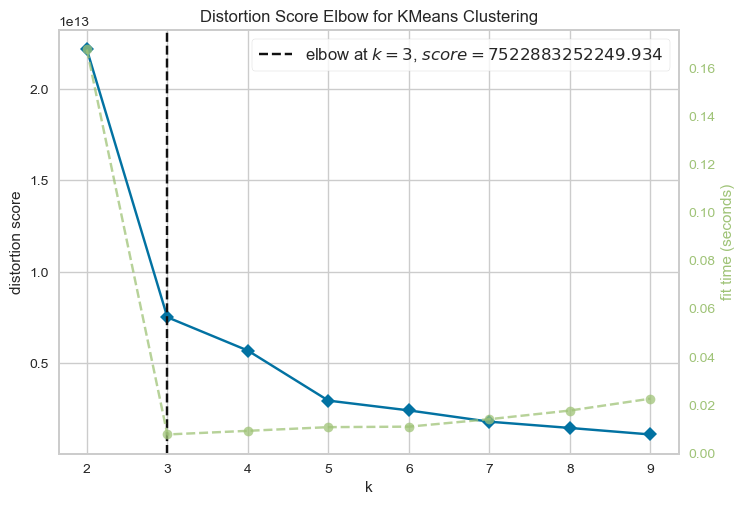

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
km = KMeans(random_state=42)
visualizer = KElbowVisualizer(km, k=(2,10))

visualizer.fit(X) # Fit the data to the visualizer
visualizer.show() # Finalize and render the figure

In [24]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [26]:
model = KMeans(3)


In [28]:
model = model.fit(X)

In [30]:
tahmin = model.predict(X)

In [31]:
tahmin

array([2, 2, 2, ..., 2, 2, 2], dtype=int32)

In [33]:
X['cluster'] = tahmin

In [35]:
X.head()

,Passenger Count,Activity Type Code_Enplaned,Activity Type Code_Thru / Transit,Price Category Code_Other,GEO Summary_International,cluster
0,27271,False,False,False,False,2
1,29131,True,False,False,False,2
2,5415,False,True,False,False,2
3,35156,False,False,True,True,2
4,34090,True,False,True,True,2


In [36]:
silhouette_score(X , tahmin)

np.float64(0.8283149612168751)

In [38]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'cluster')

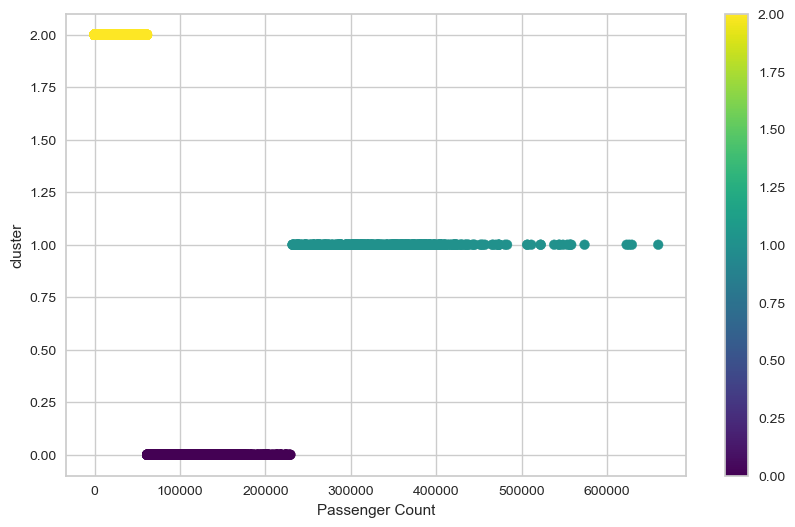

In [46]:
plt.figure(figsize= (10,6))
plt.scatter(X['Passenger Count'],X['cluster'] , c=tahmin,  cmap='viridis')
plt.colorbar();
plt.xlabel("Passenger Count")
plt.ylabel("cluster")

In [47]:
# End of Homework